# MobileNetV2 — Edible Plants (62 Classes)
> Works on **Google Colab** and **Local Jupyter** · Target ≥90%
> Models saved permanently — auto-uploaded to Drive from local

In [1]:
import sys, os, gc, random, shutil
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau,
                                         ModelCheckpoint)
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, precision_score,
                              recall_score, f1_score)
import seaborn as sns

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

# ── Environment detection ─────────────────────────────────────────────────
IS_COLAB = 'google.colab' in sys.modules
print(f"Environment : {'Google Colab' if IS_COLAB else 'Local (Jupyter)'}")
print(f"TF version  : {tf.__version__}")
print(f"GPU         : {tf.config.list_physical_devices('GPU')}")

Environment : Google Colab
TF version  : 2.19.0
GPU         : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# ── Storage setup (works on both Colab and Localhost) ─────────────────────
IS_COLAB = 'google.colab' in sys.modules

if IS_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_DIR  = '/content/drive/MyDrive/edible_plants_models'
    DATA_ROOT  = '/content/plant_data'
else:
    # Local: save models in the project folder next to this notebook
    import pathlib
    PROJECT_DIR = str(pathlib.Path.cwd())
    DRIVE_DIR   = os.path.join(PROJECT_DIR, 'saved_models')
    DATA_ROOT   = os.path.join(PROJECT_DIR, 'plant_data')

os.makedirs(DRIVE_DIR, exist_ok=True)
os.makedirs(DATA_ROOT, exist_ok=True)

TRAIN_DIR = os.path.join(DATA_ROOT, 'train')
VAL_DIR   = os.path.join(DATA_ROOT, 'val')
TEST_DIR  = os.path.join(DATA_ROOT, 'test')

print(f"Model save dir : {DRIVE_DIR}")
print(f"Data root      : {DATA_ROOT}")

Mounted at /content/drive
Model save dir : /content/drive/MyDrive/edible_plants_models
Data root      : /content/plant_data


In [3]:
!pip install kagglehub -q
import kagglehub

path = kagglehub.dataset_download("gverzea/edible-wild-plants")
print("Dataset path:", path)

100%|██████████| 766M/766M [00:08<00:00, 95.6MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/gverzea/edible-wild-plants/versions/5


In [4]:
def find_class_root(base):
    for root, dirs, files in os.walk(base):
        if len(dirs) > 50:
            sample = os.path.join(root, dirs[0])
            if os.path.isdir(sample):
                imgs = [f for f in os.listdir(sample)
                        if f.lower().endswith(('.jpg','.jpeg','.png'))]
                if imgs: return root
    return None

SOURCE_DIR = find_class_root(path)
if SOURCE_DIR is None:
    raise RuntimeError("Cannot find class root — re-run dataset download")

GOOD_FOLDERS = [d for d in sorted(os.listdir(SOURCE_DIR))
                if os.path.isdir(os.path.join(SOURCE_DIR, d))
                and any(f.lower().endswith(('.jpg','.jpeg','.png'))
                        for f in os.listdir(os.path.join(SOURCE_DIR, d)))]
print(f"SOURCE_DIR         : {SOURCE_DIR}")
print(f"Valid class folders: {len(GOOD_FOLDERS)}")

SOURCE_DIR         : /root/.cache/kagglehub/datasets/gverzea/edible-wild-plants/versions/5/datasets/dataset
Valid class folders: 62


In [5]:
# Only rebuild if train folder doesn't exist or is empty
if not os.path.exists(TRAIN_DIR) or len(os.listdir(TRAIN_DIR)) == 0:
    if os.path.exists(DATA_ROOT):
        shutil.rmtree(DATA_ROOT)
    os.makedirs(DATA_ROOT)

    def make_split(source, base, classes, seed=42, train_r=0.80, val_r=0.10):
        random.seed(seed); skipped = []
        for cls in classes:
            src = os.path.join(source, cls)
            imgs = [f for f in os.listdir(src)
                    if f.lower().endswith(('.jpg','.jpeg','.png'))
                    and os.path.isfile(os.path.join(src, f))]
            if len(imgs) < 5: skipped.append(cls); continue
            random.shuffle(imgs)
            n_tr = int(len(imgs) * train_r)
            n_v  = max(int(len(imgs) * val_r), 1)
            for dest, flist in [
                (os.path.join(base,'train',cls), imgs[:n_tr]),
                (os.path.join(base,'val',  cls), imgs[n_tr:n_tr+n_v]),
                (os.path.join(base,'test', cls), imgs[n_tr+n_v:])
            ]:
                os.makedirs(dest, exist_ok=True)
                for f in flist:
                    shutil.copy2(os.path.join(src, f), os.path.join(dest, f))
        return skipped

    print("Creating 80/10/10 split …")
    skipped = make_split(SOURCE_DIR, DATA_ROOT, GOOD_FOLDERS)
    if skipped: print(f"Skipped (too few images): {skipped}")
else:
    print("Split already exists — skipping rebuild.")

for split, d in [('train',TRAIN_DIR),('val',VAL_DIR),('test',TEST_DIR)]:
    if os.path.exists(d):
        nc = len([c for c in os.listdir(d) if os.path.isdir(os.path.join(d,c))])
        ni = sum(len(os.listdir(os.path.join(d,c)))
                 for c in os.listdir(d) if os.path.isdir(os.path.join(d,c)))
        print(f"  {split}: {nc} classes, {ni} images")

Creating 80/10/10 split …
  train: 62 classes, 5246 images
  val: 62 classes, 655 images
  test: 62 classes, 657 images


In [6]:
IMG_SIZE = (224, 224); BATCH_SIZE = 8; SEED = 42
tf.keras.backend.clear_session(); gc.collect()
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
train_gen = ImageDataGenerator(preprocessing_function=preprocess_input,
    rotation_range=30, width_shift_range=0.15, height_shift_range=0.15,
    shear_range=0.15, zoom_range=0.2, horizontal_flip=True,
    brightness_range=[0.8,1.2], fill_mode='nearest')
vt_gen = ImageDataGenerator(preprocessing_function=preprocess_input)
train_ds = train_gen.flow_from_directory(TRAIN_DIR, target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical', seed=SEED, shuffle=True)
val_ds   = vt_gen.flow_from_directory(VAL_DIR, target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical', seed=SEED, shuffle=False)
test_ds  = vt_gen.flow_from_directory(TEST_DIR, target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical', seed=SEED, shuffle=False)
classes = list(train_ds.class_indices.keys()); NUM_CLASSES = len(classes)
STEPS    = max(int(np.ceil(train_ds.samples / BATCH_SIZE)), 1)
VAL_STP  = max(int(np.ceil(val_ds.samples   / BATCH_SIZE)), 1)
TEST_STP = max(int(np.ceil(test_ds.samples  / BATCH_SIZE)), 1)
print(f"Classes:{NUM_CLASSES}  Train:{train_ds.samples}  Val:{val_ds.samples}  Test:{test_ds.samples}")

Found 5246 images belonging to 62 classes.
Found 655 images belonging to 62 classes.
Found 657 images belonging to 62 classes.
Classes:62  Train:5246  Val:655  Test:657


In [7]:
tf.keras.backend.clear_session(); gc.collect()
base_model = tf.keras.applications.MobileNetV2(input_shape=(*IMG_SIZE,3),
    include_top=False, weights='imagenet')
base_model.trainable = False
inp = layers.Input(shape=(*IMG_SIZE,3))
x = base_model(inp, training=False)
x = layers.GlobalAveragePooling2D()(x); x = layers.BatchNormalization()(x)
x = layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(5e-5))(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(5e-5))(x)
x = layers.Dropout(0.3)(x)
out = layers.Dense(NUM_CLASSES, activation='softmax')(x)
model = models.Model(inp, out); model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 62)             │        15,934 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,066,238 (11.70 MB)

 Trainable params: 805,694 (3.07 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [8]:
P1_CKPT    = os.path.join(DRIVE_DIR, 'MobileNetV2_phase1_best.weights.h5')
FINAL_PATH = os.path.join(DRIVE_DIR, 'MobileNetV2_edible_plants.keras')
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')])
cb_p1 = [EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1),
         ReduceLROnPlateau(monitor='val_loss', factor=0.4, patience=3, min_lr=1e-7, verbose=1),
         ModelCheckpoint(P1_CKPT, monitor='val_accuracy',
                         save_best_only=True, save_weights_only=True, verbose=1)]
print(f"Phase 1 checkpoint -> {P1_CKPT}")
print("=== Phase 1: Head training (base FROZEN) ===")
h1 = model.fit(train_ds, epochs=30, steps_per_epoch=STEPS,
               validation_data=val_ds, validation_steps=VAL_STP,
               callbacks=cb_p1, verbose=1)
print(f"Phase 1 best val_accuracy: {max(h1.history['val_accuracy']):.4f}")
gc.collect()

Phase 1 checkpoint -> /content/drive/MyDrive/edible_plants_models/MobileNetV2_phase1_best.weights.h5
=== Phase 1: Head training (base FROZEN) ===
Epoch 1/30
656/656 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.3076 - auc: 0.7960 - loss: 3.4262 - precision: 0.7663 - recall: 0.1841
Epoch 1: val_accuracy improved from None to 0.52366, saving model to /content/drive/MyDrive/edible_plants_models/MobileNetV2_phase1_best.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/edible_plants_models/MobileNetV2_phase1_best.weights.h5
656/656 ━━━━━━━━━━━━━━━━━━━━ 147s 182ms/step - accuracy: 0.3578 - auc: 0.8486 - loss: 3.1397 - precision: 0.8154 - recall: 0.2205 - val_accuracy: 0.5237 - val_auc: 0.9439 - val_loss: 2.4507 - val_precision: 0.9035 - val_recall: 0.3145 - learning_rate: 0.0010
Epoch 2/30
656/656 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.4289 - auc: 0.9086 - loss: 2.7950 - precision: 0.8310 - recall: 0.2588
Epoch 2: val_accuracy improved from 0.52366 to 0.54351,

2166

In [10]:
P2_CKPT = os.path.join(DRIVE_DIR, 'MobileNetV2_phase2_best.weights.h5')
model.load_weights(P1_CKPT)
base_model.trainable = True
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization): layer.trainable = False
for layer in base_model.layers[:-50]: layer.trainable = False
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=2e-5, decay_steps=max(STEPS*40,1), alpha=1e-7)
model.compile(optimizer=tf.keras.optimizers.Adam(lr_schedule),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')])
cb_p2 = [EarlyStopping(monitor='val_accuracy', patience=12, restore_best_weights=True, verbose=1),
         ModelCheckpoint(P2_CKPT, monitor='val_accuracy',
                         save_best_only=True, save_weights_only=True, verbose=1)]
print(f"Phase 2 checkpoint -> {P2_CKPT}")
print("=== Phase 2: Fine-tuning top-50 base layers ===")
gc.collect()
h2 = model.fit(train_ds, epochs=15, steps_per_epoch=STEPS,
               validation_data=val_ds, validation_steps=VAL_STP,
               callbacks=cb_p2, verbose=1)
print(f"Phase 2 best val_accuracy: {max(h2.history['val_accuracy']):.4f}")
gc.collect()

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 51 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Phase 2 checkpoint -> /content/drive/MyDrive/edible_plants_models/MobileNetV2_phase2_best.weights.h5
=== Phase 2: Fine-tuning top-50 base layers ===
Epoch 1/15
656/656 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.7149 - auc: 0.9864 - loss: 1.5896 - precision: 0.8983 - recall: 0.5535
Epoch 1: val_accuracy improved from None to 0.70382, saving model to /content/drive/MyDrive/edible_plants_models/MobileNetV2_phase2_best.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/edible_plants_models/MobileNetV2_phase2_best.weights.h5
656/656 ━━━━━━━━━━━━━━━━━━━━ 122s 163ms/step - accuracy: 0.7144 - auc: 0.9859 - loss: 1.5797 - precision: 0.8898 - recall: 0.5646 - val_accuracy: 0.7038 - val_auc: 0.9723 - val_loss: 1.6701 - val_precision: 0.8544 - val_recall: 0.6183
Epoch 2/15
656/656 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.7402 - auc: 0.9869 - loss: 1.5199 - precision: 0.8898 - recall: 0.5937
Epoch 2: val_accuracy improved from 0.70382 to 0.72519, saving model to /con

4192

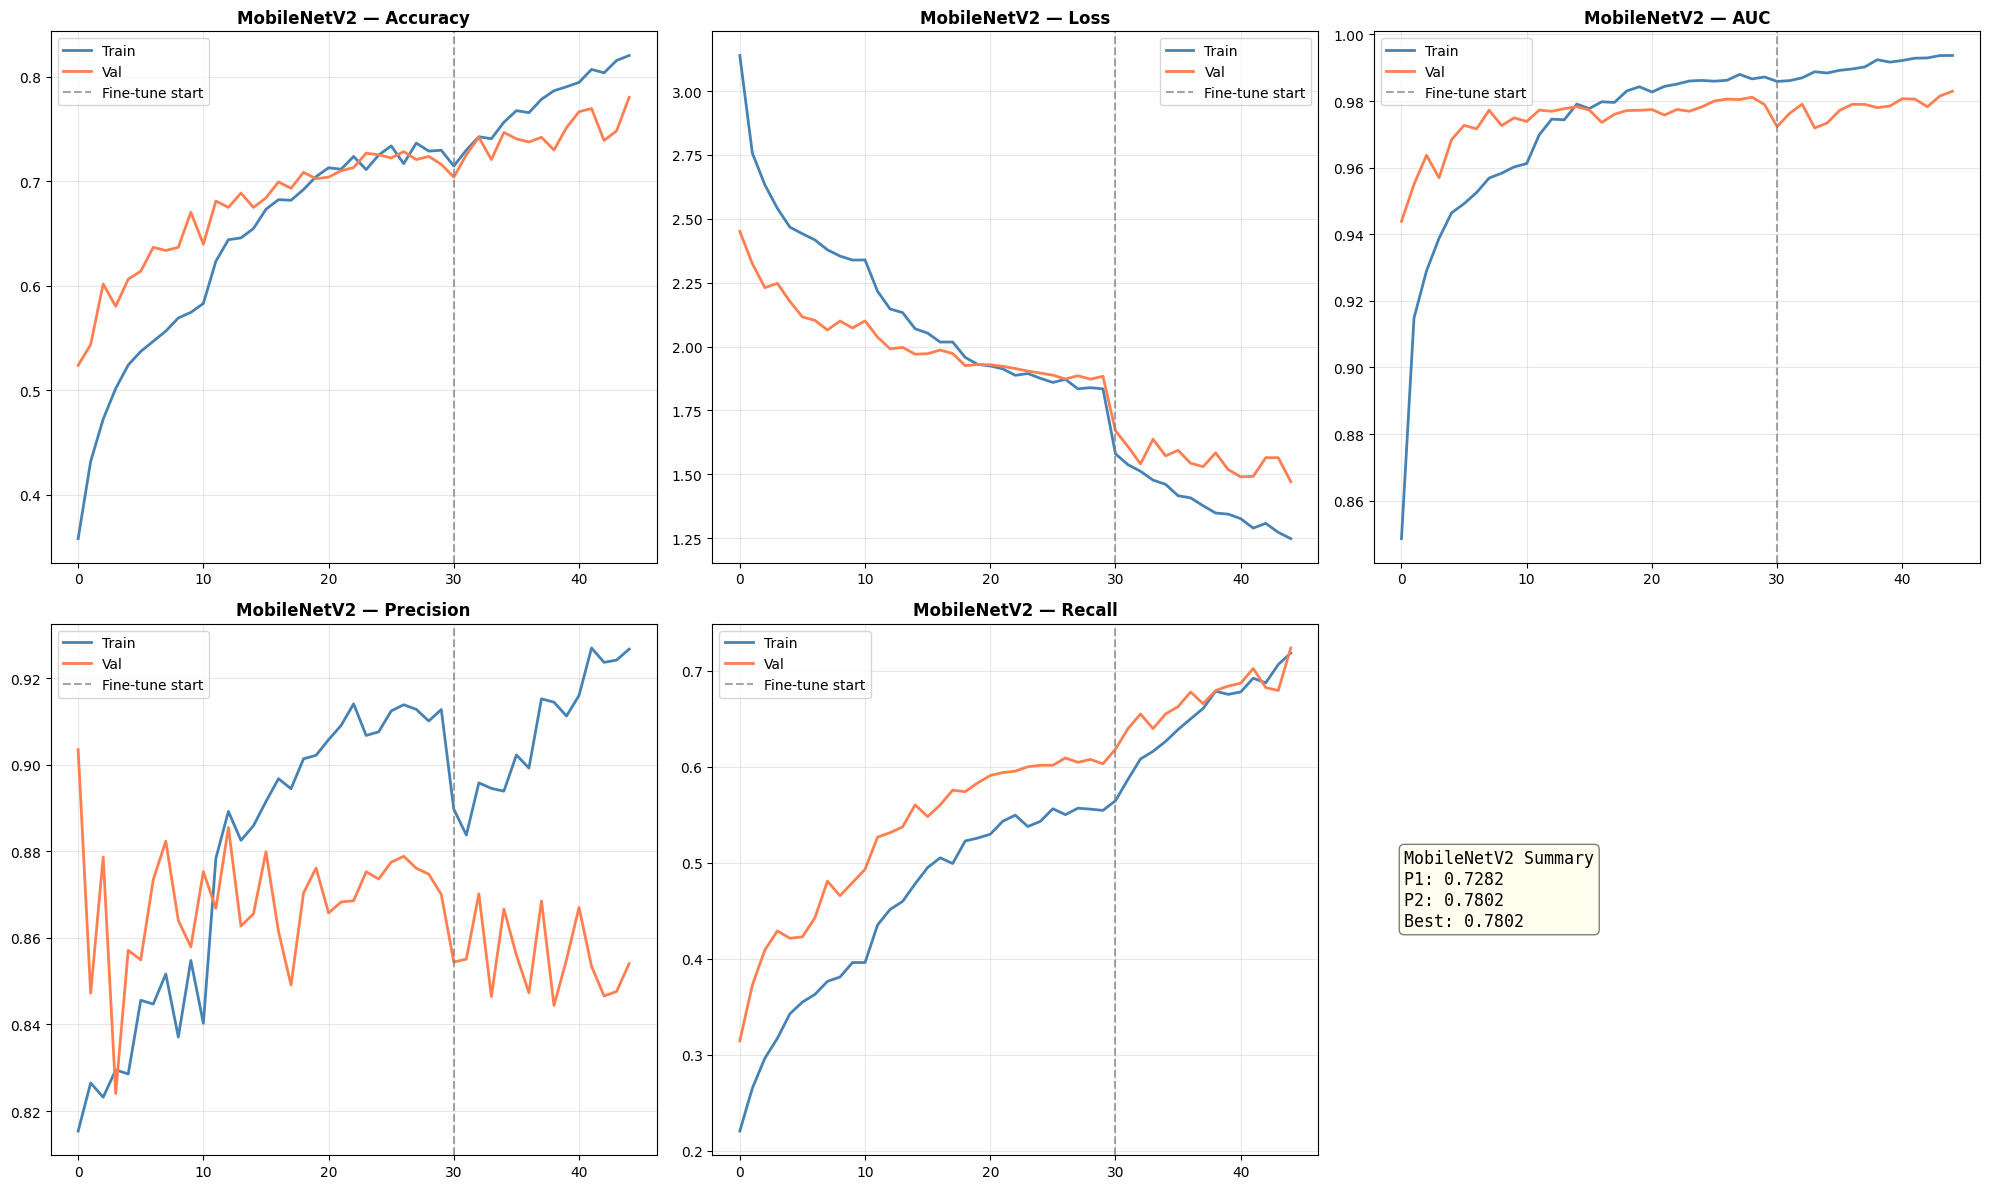

In [11]:
def combine(h1, h2, key): return h1.history.get(key,[]) + h2.history.get(key,[])
phase1_end = len(h1.history['accuracy'])
pairs = [('accuracy','val_accuracy','Accuracy'),('loss','val_loss','Loss'),
         ('auc','val_auc','AUC'),('precision','val_precision','Precision'),('recall','val_recall','Recall')]
fig, axes = plt.subplots(2, 3, figsize=(20,12))
for ax,(tr,vl,title) in zip(axes.flat, pairs):
    ax.plot(combine(h1,h2,tr), color='steelblue', lw=2, label='Train')
    ax.plot(combine(h1,h2,vl), color='coral',     lw=2, label='Val')
    ax.axvline(phase1_end, color='gray', linestyle='--', alpha=0.7, label='Fine-tune start')
    ax.set_title(f'MobileNetV2 — {title}', fontweight='bold'); ax.legend(); ax.grid(alpha=0.3)
ax_s = axes.flat[-1]; ax_s.axis('off')
ax_s.text(0.05,0.5, f"MobileNetV2 Summary\nP1: {max(h1.history['val_accuracy']):.4f}\nP2: {max(h2.history['val_accuracy']):.4f}\nBest: {max(combine(h1,h2,'val_accuracy')):.4f}",
    fontsize=12,family='monospace',verticalalignment='center',
    bbox=dict(boxstyle='round',facecolor='lightyellow',alpha=0.5))
plt.tight_layout(); plt.show()

In [12]:
print("Running streaming predictions on test set …")
y_pred_list = []; y_true_list = []
test_ds.reset()
for batch_x, batch_y in test_ds:
    preds = model.predict_on_batch(batch_x)
    y_pred_list.append(np.argmax(preds,   axis=1))
    y_true_list.append(np.argmax(batch_y, axis=1))
    if len(y_pred_list) >= TEST_STP: break
y_pred = np.concatenate(y_pred_list)
y_true = np.concatenate(y_true_list)
del y_pred_list, y_true_list; gc.collect()
n = min(len(y_pred), len(y_true)); y_pred, y_true = y_pred[:n], y_true[:n]

acc  = accuracy_score (y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
rec  = recall_score   (y_true, y_pred, average='weighted', zero_division=0)
f1   = f1_score       (y_true, y_pred, average='weighted', zero_division=0)
print(f"\n  Accuracy  : {acc:.4f}")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print(f"  Grade     : {'EXCELLENT (>=90%)' if acc>=0.90 else 'GOOD (>=80%)' if acc>=0.80 else 'Needs tuning'}")
print("\n—— Classification Report ——")
print(classification_report(y_true, y_pred, labels=np.arange(len(classes)),
                             target_names=classes, zero_division=0))

Running streaming predictions on test set …

  Accuracy  : 0.7717
  Precision : 0.7824
  Recall    : 0.7717
  F1-Score  : 0.7671
  Grade     : Needs tuning

—— Classification Report ——
                     precision    recall  f1-score   support

            Alfalfa       0.50      0.20      0.29         5
          Asparagus       1.00      0.90      0.95        10
       Blue Vervain       0.67      0.40      0.50         5
 Broadleaf Plantain       0.36      0.80      0.50         5
       Bull Thistle       0.67      0.40      0.50         5
            Cattail       1.00      1.00      1.00         5
          Chickweed       0.79      0.73      0.76        15
            Chicory       0.60      0.60      0.60         5
           Cleavers       0.40      0.40      0.40         5
          Coltsfoot       0.75      0.60      0.67         5
 Common Sow Thistle       1.00      0.60      0.75        10
      Common Yarrow       0.33      0.40      0.36         5
         Coneflower  

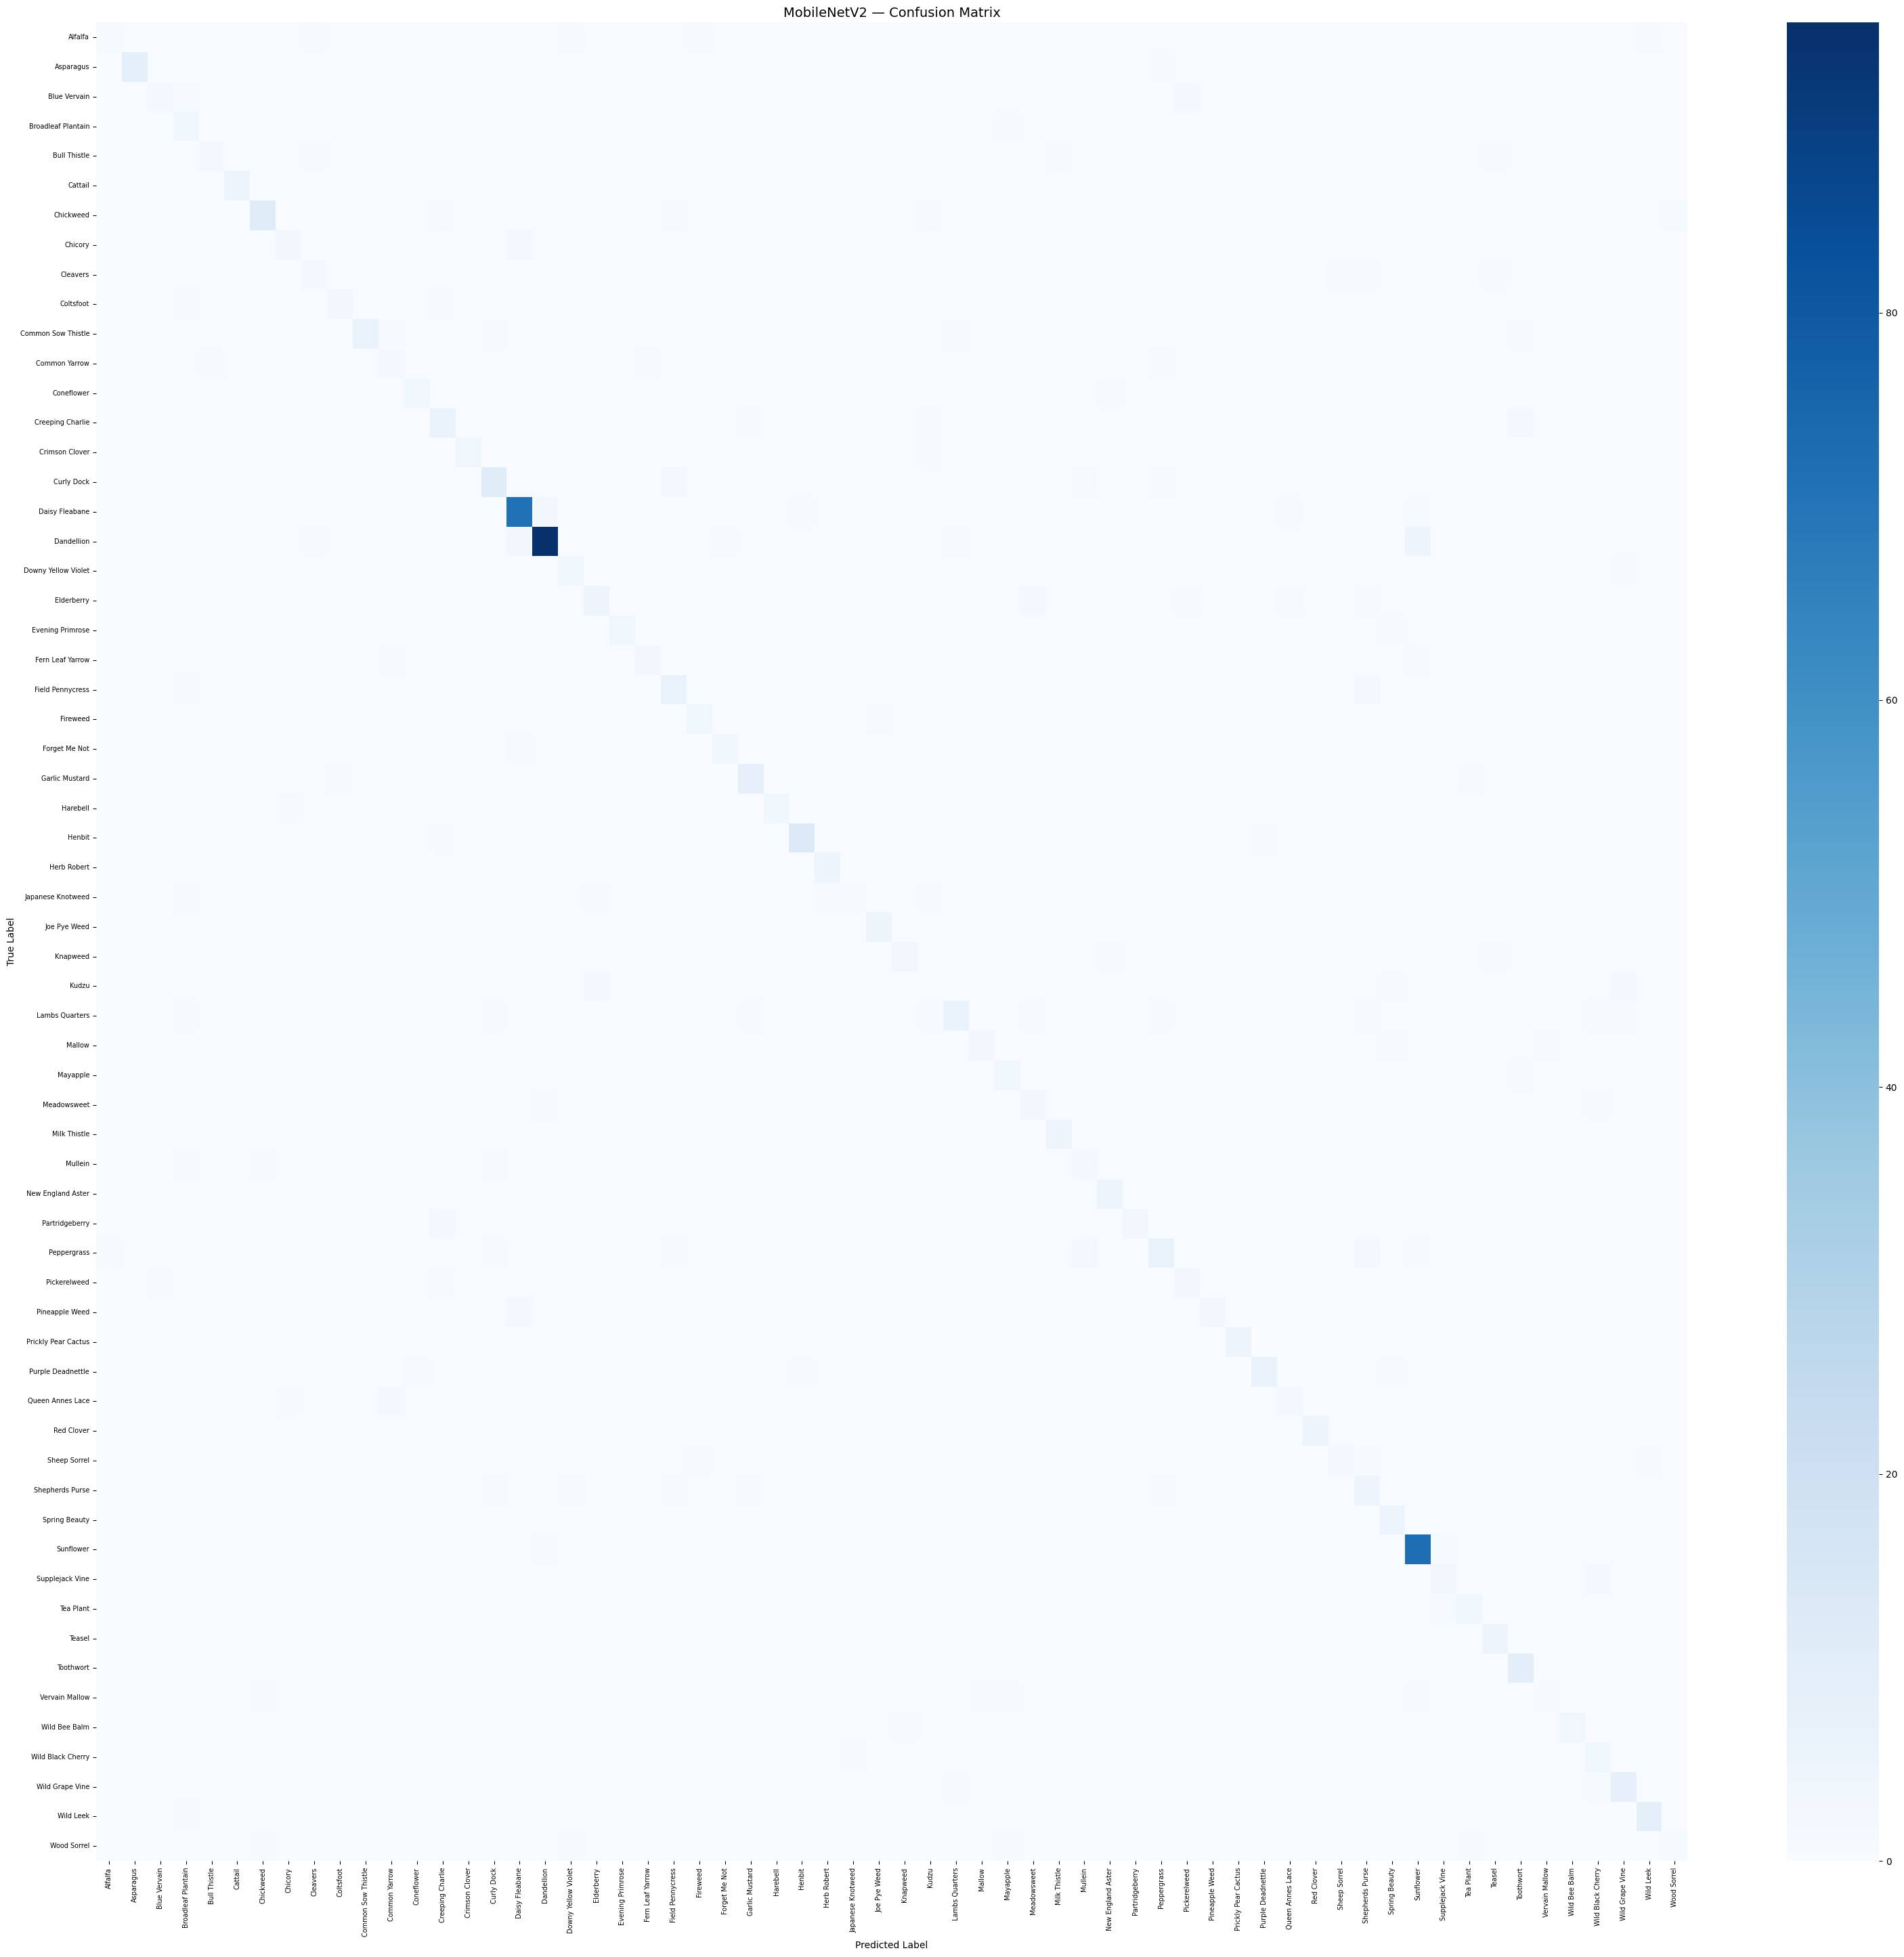

16524

In [13]:
cm  = confusion_matrix(y_true, y_pred, labels=np.arange(len(classes)))
fsz = max(10, len(classes)//2)
plt.figure(figsize=(fsz, fsz-2))
sns.heatmap(cm, annot=(len(classes)<=20), fmt='d',
            xticklabels=classes, yticklabels=classes, cmap='Blues')
plt.title('MobileNetV2 — Confusion Matrix', fontsize=14)
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.xticks(rotation=90, fontsize=7); plt.yticks(rotation=0, fontsize=7)
plt.tight_layout(); plt.show()
del y_pred, y_true; gc.collect()

In [14]:
model.save(FINAL_PATH)
print(f"Model saved: {FINAL_PATH}")
gc.collect(); tf.keras.backend.clear_session()

Model saved: /content/drive/MyDrive/edible_plants_models/MobileNetV2_edible_plants.keras


In [15]:
# ── Upload ALL saved files to Google Drive ────────────────────────────────
# Uploads: phase1 checkpoint, phase2 checkpoint, final .keras model
# Works from LOCAL machine only. Skipped automatically on Colab.
IS_COLAB = 'google.colab' in sys.modules

if IS_COLAB:
    print("Running on Colab — all files already saved to Drive. Nothing to upload.")
else:
    print("Running locally — uploading all files from saved_models/ to Google Drive …")
    try:
        import subprocess as _sp, sys as _sys
        _sp.check_call([_sys.executable, '-m', 'pip', 'install', 'pydrive2', '-q'])

        from pydrive2.auth import GoogleAuth
        from pydrive2.drive import GoogleDrive

        # One-time browser login (cached after first run)
        gauth = GoogleAuth()
        gauth.LocalWebserverAuth()
        gdrive = GoogleDrive(gauth)

        # Find or create 'edible_plants_models' folder in Drive root
        folder_list = gdrive.ListFile(
            {'q': "title='edible_plants_models' and "
                  "mimeType='application/vnd.google-apps.folder' and "
                  "trashed=false"}
        ).GetList()

        if folder_list:
            folder_id = folder_list[0]['id']
            print(f"Found Drive folder  : edible_plants_models (id={folder_id})")
        else:
            folder = gdrive.CreateFile({
                'title': 'edible_plants_models',
                'mimeType': 'application/vnd.google-apps.folder'
            })
            folder.Upload()
            folder_id = folder['id']
            print(f"Created Drive folder: edible_plants_models (id={folder_id})")

        # Upload every file inside DRIVE_DIR (saved_models/)
        all_files = [f for f in os.listdir(DRIVE_DIR)
                     if os.path.isfile(os.path.join(DRIVE_DIR, f))]

        if not all_files:
            print("No files found in saved_models/ — make sure training completed.")
        else:
            print(f"\nUploading {len(all_files)} file(s):")
            for fname in sorted(all_files):
                local_path = os.path.join(DRIVE_DIR, fname)
                size_mb = os.path.getsize(local_path) / (1024 * 1024)

                # Check if file already exists in Drive folder → update it
                existing = gdrive.ListFile(
                    {'q': f"title='{fname}' and '{folder_id}' in parents and trashed=false"}
                ).GetList()

                if existing:
                    gfile = existing[0]
                    gfile.SetContentFile(local_path)
                    gfile.Upload()
                    print(f"  Updated  {fname:50s}  ({size_mb:.1f} MB)")
                else:
                    gfile = gdrive.CreateFile({
                        'title': fname,
                        'parents': [{'id': folder_id}]
                    })
                    gfile.SetContentFile(local_path)
                    gfile.Upload()
                    print(f"  Uploaded {fname:50s}  ({size_mb:.1f} MB)")

            print("\nAll files uploaded to Drive/edible_plants_models/")
            print("Open modelcomparison.ipynb on Colab to compare all models.")

    except Exception as e:
        print(f"Auto-upload failed: {e}")
        print("\nManual option:")
        print(f"  Go to drive.google.com → My Drive")
        print(f"  Create folder 'edible_plants_models' if it doesn't exist")
        print(f"  Upload all files from: {DRIVE_DIR}")

Running on Colab — all files already saved to Drive. Nothing to upload.
